In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import itertools
from typing import Tuple, Union, Sequence
import pandas as pd
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1TeQoeJ0T30m06s7_OyWuTN5VVoMHM-SD/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble


In [ ]:
marlin_dataset = np.load('marlin_embeddings_unified.npy')
print(marlin_dataset.shape)

(941, 768)


In [ ]:
keyframe_dataset = np.load('unified_keyframe_embeddings_256.npy')
print(keyframe_dataset.shape)

(941, 256)


In [ ]:
### check if any of the embeddings in marlin are the 0 vector
# Check if any row in marlin_dataset is all zeros
zero_vector_mask = np.all(keyframe_dataset == 0, axis=1)
num_zero_vectors = np.sum(zero_vector_mask)

print(f"Number of zero vectors: {num_zero_vectors}")

Number of zero vectors: 0


In [ ]:
### check if any of the embeddings in marlin are the 0 vector
# Check if any row in marlin_dataset is all zeros
zero_vector_mask = np.all(marlin_dataset == 0, axis=1)
num_zero_vectors = np.sum(zero_vector_mask)

print(f"Number of zero vectors: {num_zero_vectors}")


Number of zero vectors: 0


In [ ]:
### Threshold Calculation Functions ###

"""
Returns the score threshold for which there are no false
negatives with a lower score.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""

def min_fnr_threshold(probs, Y_val):
  pos_scores = probs[Y_val == 1]
  return pos_scores.min()


"""
Returns the score threshold for which there are no false
positives with a higher score.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""
def min_fpr_threshold(probs, Y_val):
  neg_scores = probs[Y_val == 0]
  return neg_scores.max()


"""
Returns the approximate score threshold that
maximizes accuracy.

probs: List of probabilities of being in class 1
Y_val: Labels of the validation set
"""
def max_acc_threshold(probs, Y_val):
    best_acc = 0
    best_thresh_acc = None

    for t in np.arange(0.01, 1.0, 0.01):
        preds = (probs > t).astype(int)
        acc = accuracy_score(Y_val, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = t

    return best_thresh_acc

In [ ]:
### Dataset Splitting Functions ###
"""
    Split (X, y) into train / validation / test sets with arbitrary ratios.

    Parameters
    ----------
    train_ratio, val_ratio, test_ratio : float, default 0.7 / 0.2 / 0.1
        Fractions (must sum to 1).  They are interpreted **relative to the whole
        dataset**, e.g. 0.1 means “10 % of all samples.”
    random_state : int, default 42
        Seed for reproducibility.
    stratify : bool, default True
        If True, keeps class proportions by stratifying on `y`.

    Returns
    -------
    X_train, X_val, X_test, y_train, y_val, y_test
"""
def split_data(
        X: Union[np.ndarray, Sequence],
        y: Union[np.ndarray, Sequence],
        *,
        train_ratio: float = 0.7,
        val_ratio:   float = 0.2,
        test_ratio:  float = 0.1,
        random_state: int = 42,
        stratify: bool = True
) -> Tuple[np.ndarray, np.ndarray, np.ndarray,
           np.ndarray, np.ndarray, np.ndarray]:

    # --- Sanity checks ------------------------------------------------------
    total = train_ratio + val_ratio + test_ratio
    if not np.isclose(total, 1.0):
        raise ValueError(f"Ratios must sum to 1 (got {total:.3f}).")
    if min(train_ratio, val_ratio, test_ratio) < 0:
        raise ValueError("Ratios must be non-negative.")

    strat_full = y if stratify else None

    # --- first split: train vs. temp ---------------------------------------
    temp_ratio = val_ratio + test_ratio          # e.g. 0.30 in the 70/20/10 case

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=temp_ratio,
        random_state=random_state,
        shuffle=True,
        stratify=strat_full
    )

    # --- second split: val vs. test inside the temp chunk ------------------
    # test share *within* the temp chunk:
    test_share_of_temp = test_ratio / temp_ratio if temp_ratio > 0 else 0.0

    strat_temp = y_temp if stratify else None

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=test_share_of_temp,
        random_state=random_state,
        shuffle=True,
        stratify=strat_temp
    )

    return np.array(X_train), np.array(X_val), np.array(X_test), np.array(y_train), np.array(y_val), np.array(y_test)

In [ ]:
### Data splitting (by indices) ### (70-15-15) is default
"""
Splits a given dataset into training, validation, and test sets.
Default split is 70-15-15.

Returns the indices of the examples in each of the splits.
"""
def split_by_indices(n_samples, train_frac=0.7, val_frac=0.15, test_frac=0.15, random_state=None):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6, "Fractions must sum to 1."

    # Shuffle indices
    indices = np.arange(n_samples)
    rng = np.random.default_rng(seed=random_state)
    rng.shuffle(indices)

    # Compute split sizes
    train_end = int(train_frac * n_samples)
    val_end = train_end + int(val_frac * n_samples)

    # Split indices
    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    return train_idx, val_idx, test_idx

"""
Splits a given dataset into training, validation, and test sets
given the indices to use for each split.

"""
def split_data_from_indices(X, y, train_idx, val_idx, test_idx):
  # Slice datasets and convert to NumPy arrays
  X_train, Y_train = np.array([X[idx] for idx in train_idx]), np.array([y[idx] for idx in train_idx])
  X_val, Y_val = np.array([X[idx] for idx in val_idx]), np.array([y[idx] for idx in val_idx])
  X_test, Y_test = np.array([X[idx] for idx in test_idx]), np.array([y[idx] for idx in test_idx])

  return X_train, X_val, X_test, Y_train, Y_val, Y_test

In [ ]:
class LogisticModule:
    def __init__(self, logistic_module):
        self.logistic_module = logistic_module
        self.threshold = 0.5 # Base Threshold for a logistic Regressor

    """
    Given training data and labels, train the logistic regression
    layer of the module.
    """
    def train_logistic_module(self, X_train, Y_train, max_iters=100):
      self.logistic_module.max_iter = max_iters # Set max_iters on the instance
      self.logistic_module.fit(X_train, Y_train)

    """
    Uses the validation set to obtain
    the threshold for classification, as described
    by a given function, for the logistic regressor.
    If no function is provided, the default is to use 0.5.

    Returns the computed threshold.
    """
    def set_threshold(self, X_val, Y_val, threshold_selection_fn=None):
      if threshold_selection_fn is None:
        self.threshold = 0.5
        return 0.5
      # Get the class-1 probabilities on *validation* data
      probs = self.logistic_module.predict_proba(X_val)[:, 1]

      threshold = threshold_selection_fn(probs, Y_val.ravel())

      # Update the threshold
      self.threshold = threshold
      return threshold

    """
    Tests the module and outputs accuracy, F1, and AUC.

    Will display confusion matrices.
    """
    def evaluate_module(self, X_test, Y_test, display_title=None):
      y_probs = self.logistic_module.predict_proba(X_test)[:,1]
      y_pred = (y_probs >= self.threshold).astype(int)

      # Compute confusion matrix
      cm = confusion_matrix(Y_test, y_pred)
      tn, fp, fn, tp = cm.ravel()

      # Display confusion matrix
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.logistic_module.classes_)
      disp.plot(cmap='Blues')
      plt.title(f"Confusion Matrix (threshold = {self.threshold})")
      plt.show()

      # Compute metrics
      roc_auc = roc_auc_score(Y_test, y_probs)
      f1 = f1_score(Y_test, y_pred)
      acc = accuracy_score(Y_test, y_pred)

      # Save metrics in a dictionary
      results = {"Accuracy" : acc, "F1": f1, "ROC AUC": roc_auc}
      return results

    """
    Predict the score of a given example/embedding x

    Must be in array-like format.
    """
    def predict_score(self, x):
      score = self.logistic_module.predict_proba(x)[:,1]
      return score[0]


    """
    Predict the label of a given example/embedding x

    Must be in array-like format.
    """
    def predict_label(self, x):
      label = self.logistic_module.predict(x)
      return label[0]

In [ ]:
### Example Code ###
video_dataset = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1, 1) # Embeddings
labels = np.array([0,0,0,0,0,1,1,1,1,1]).reshape(-1, 1) # Real - 0, Fake - 1
# X_train, X_val, X_test, Y_train, Y_val, Y_test = split_data(video_dataset, labels)
logistic_regressor1 = LogisticRegression()
ensemble_layer1 = LogisticModule(logistic_regressor1)

# Train it on the dataset
ensemble_layer1.train_logistic_module(X_train, Y_train)

# Set the threshold
threshold_functions = [min_fnr_threshold, min_fpr_threshold, max_acc_threshold]

# Pick one of the three
thres_func = threshold_functions[0]
ensemble_layer1.set_threshold(X_val, Y_val, thres_func)

# Evaluate the model
ensemble_layer1.evaluate_module(X_test, Y_test)

# Predict score
print(ensemble_layer1.predict_score(np.array([[5.5]])))
print(ensemble_layer1.predict_label(np.array([[5.5]])))

NameError: name 'X_train' is not defined

In [ ]:
### Load in embeddings, labels

video_dataset = np.load("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/marlin_embeddings_unified.npy")
with open("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/marlin_labels.pkl", "rb") as f:
    labels = pickle.load(f)

audio_dataset = np.load("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/unified_hubert_embeddings.npy")
with open("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/unified_hubert_labels.pkl", "rb") as f:
    labels = pickle.load(f)

forensic_dataset = np.load("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/unified_keyframe_embeddings_256.npy")
with open("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/unified_keyframe_labels_256.pkl", "rb") as f:
    labels = pickle.load(f)

### Use unified_datset_with_perturbations.pkl
### the overall labels is the column overall_label
with open("/content/drive/MyDrive/Project_4_Deepfake_Detection/Summer 2025/Code/ricardo_ensemble/unified_dataset_with_perturbations.pkl", "rb") as f:
    y_overall = pickle.load(f)["overall_label"]

print(f"Video dataset: {video_dataset.shape}")
print(f"Audio dataset: {audio_dataset.shape}")
print(f"Forensic dataset: {forensic_dataset.shape}")
print(f"Overall labels: {y_overall.shape}")

Video dataset: (941, 768)
Audio dataset: (941, 768)
Forensic dataset: (941, 256)
Overall labels: (941,)


In [ ]:
### Training, validation, testing splits ###
n_samples = marlin_dataset.shape[0]
split_indices = split_by_indices(n_samples)
### Make the train val test splits the same for all 3 ###
X_video_train, X_video_val, X_video_test, y_video_train, y_video_val, y_video_test = split_data_from_indices(video_dataset, labels, *split_indices)
X_audio_train, X_audio_val, X_audio_test, y_audio_train, y_audio_val, y_audio_test = split_data_from_indices(audio_dataset, labels, *split_indices)
X_forensic_train, X_forensic_val, X_forensic_test, y_forensic_train, y_forensic_val, y_forensic_test = split_data_from_indices(forensic_dataset, labels, *split_indices)

y_train_overall, y_val_overall, y_test_overall, _, _, _ = split_data_from_indices(y_overall, y_overall, *split_indices)

In [ ]:
### Modules
logistic_reg_audio = LogisticRegression()
logistic_reg_video = LogisticRegression()
logistic_reg_forensic = LogisticRegression()

audio_module = LogisticModule(logistic_reg_audio)
video_module = LogisticModule(logistic_reg_video)
forensic_module = LogisticModule(logistic_reg_forensic)


In [ ]:
### Step 1: Train modality-specific logistic regressions using per-modality lables
audio_module.train_logistic_module(X_audio_train, y_audio_train, max_iters=1000)
video_module.train_logistic_module(X_video_train, y_video_train, max_iters=1000)
forensic_module.train_logistic_module(X_forensic_train, y_forensic_train, max_iters=1000)


In [ ]:
# tune thresholds (test all threshold fns and combos)
# min_fnr_threshold
# min_fpr_threshold
# max_acc_threshold
threshold_fn = max_acc_threshold

audio_module.set_threshold(X_audio_val, y_audio_val, threshold_fn)
video_module.set_threshold(X_video_val, y_video_val, threshold_fn)
forensic_module.set_threshold(X_forensic_val, y_forensic_val, threshold_fn)


np.float64(0.08)

In [ ]:
### Step 2 Prepare Ensemble inputs for training/testing using OVERALL labels

#For Hard OR Voting:
# During testing, for each clip:
#       Get modality probabilities from the trained logistic modules.
#       Apply modality thresholds.
#       If any modality triggers as fake, label the clip as FAKE.
#       Compare the ensemble’s clip-level prediction with overall_label to compute accuracy, F1, ROC-AUC, etc.


# For Random Forest Meta Learner
# for each clip
#       Get modality probabilities from the trained logistic modules.
#       Use these as features.
#       Use the overall labels (overall_label) as the target to train the Random Forest.
#       This way, the RF learns how to best combine modality signals to predict the clip’s real/fake status.

In [ ]:
def evaluate_hard_or_voting(logistic_modules_dict, thresholds_dict, X_test_dict, y_test_overall):
    """
    Evaluates the Hard OR Voting ensemble.

    Parameters:
        logistic_modules_dict: dict of {modality_name: LogisticModule}
        thresholds_dict: dict of {modality_name: threshold}
        X_test_dict: dict of {modality_name: X_test for that modality}
        y_test_overall: np.ndarray or pd.Series of overall labels (0/1)

    Returns:
        results: dict with accuracy, f1, roc_auc
    """
    y_pred_ensemble = []

    for idx in range(len(y_test_overall)):
        clip_is_fake = False
        modality_probs = []
        for modality, module in logistic_modules_dict.items():
            x_clip = X_test_dict[modality][idx:idx+1]  # keep 2D
            prob = module.predict_score(x_clip)
            modality_probs.append(prob)
            if prob > thresholds_dict[modality]:
                clip_is_fake = True
        y_pred_ensemble.append(int(clip_is_fake))

    y_pred_ensemble = np.array(y_pred_ensemble)

    acc = accuracy_score(y_test_overall, y_pred_ensemble)
    f1 = f1_score(y_test_overall, y_pred_ensemble)
    try:
        roc_auc = roc_auc_score(y_test_overall, y_pred_ensemble)
    except:
        roc_auc = np.nan

    cm = confusion_matrix(y_test_overall, y_pred_ensemble)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Hard OR Voting Confusion Matrix")
    plt.show()

    results = {"Accuracy": acc, "F1": f1, "ROC AUC": roc_auc}
    return results

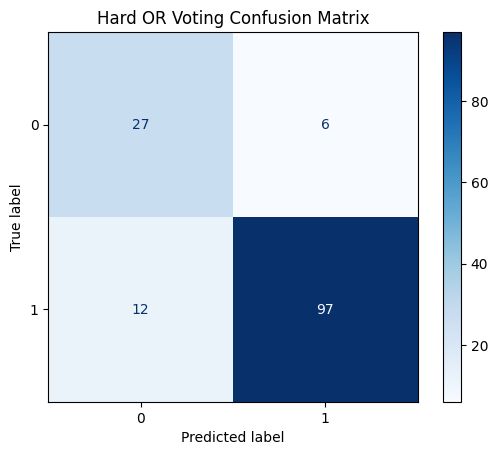

Hard OR Voting Results: {'Accuracy': 0.8732394366197183, 'F1': 0.9150943396226415, 'ROC AUC': np.float64(0.854045037531276)}


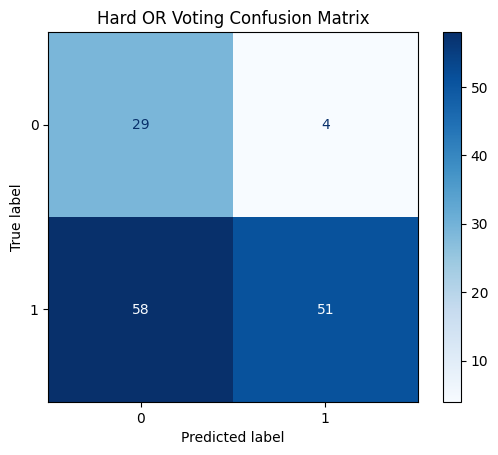

Only Audio Results: {'Accuracy': 0.5633802816901409, 'F1': 0.6219512195121951, 'ROC AUC': np.float64(0.6733388935223799)}


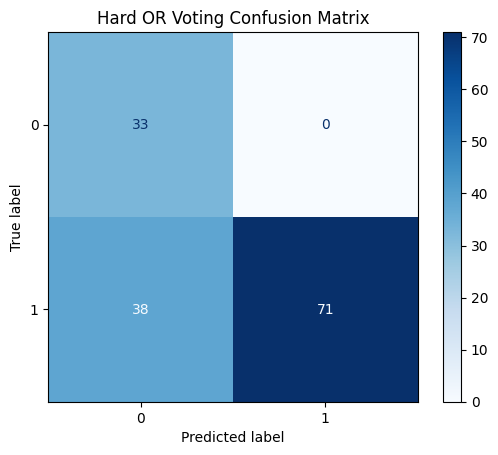

Only Video Results: {'Accuracy': 0.7323943661971831, 'F1': 0.7888888888888889, 'ROC AUC': np.float64(0.8256880733944953)}


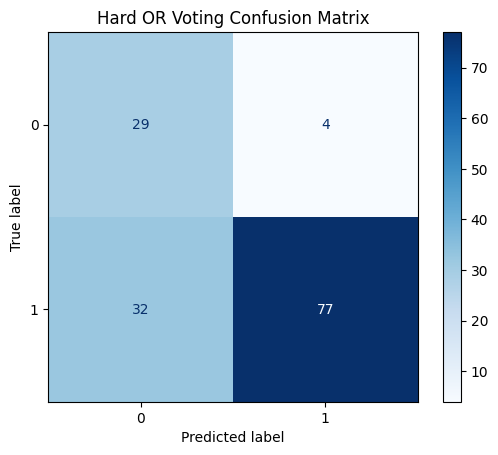

Only Forensic Results: {'Accuracy': 0.7464788732394366, 'F1': 0.8105263157894737, 'ROC AUC': np.float64(0.7926049485682514)}


In [ ]:
### Example Usage

results_or = evaluate_hard_or_voting(
    logistic_modules_dict={
        "audio": audio_module,
        "video": video_module,
        "forensic": forensic_module,
    },
    thresholds_dict={
        "audio": audio_module.threshold,
        "video": video_module.threshold,
        "forensic": forensic_module.threshold,
    },
    X_test_dict={
        "audio": X_audio_test,
        "video": X_video_test,
        "forensic": X_forensic_test,
    },
    y_test_overall=y_test_overall
)
print("Hard OR Voting Results:", results_or)

### Baseline Results (Same individual thresholds) ###
results_audio_baseline = evaluate_hard_or_voting(
    logistic_modules_dict={"Single Layer": audio_module},
    thresholds_dict={"Single Layer": audio_module.threshold},
    X_test_dict={"Single Layer": X_audio_test},
    y_test_overall=y_test_overall
    )
print("Only Audio Results:", results_audio_baseline)

results_video_baseline = evaluate_hard_or_voting(
    logistic_modules_dict={"Single Layer": video_module},
    thresholds_dict={"Single Layer": video_module.threshold},
    X_test_dict={"Single Layer": X_video_test},
    y_test_overall=y_test_overall
    )
print("Only Video Results:", results_video_baseline)

results_forensic_baseline = evaluate_hard_or_voting(
    logistic_modules_dict={"Single Layer": forensic_module},
    thresholds_dict={"Single Layer": forensic_module.threshold},
    X_test_dict={"Single Layer": X_forensic_test},
    y_test_overall=y_test_overall
    )
print("Only Forensic Results:", results_forensic_baseline)

In [ ]:
def train_and_evaluate_random_forest_ensemble(logistic_modules_dict, X_train_dict, y_train_overall,
                                              X_val_dict, y_val_overall,
                                              X_test_dict, y_test_overall,
                                              n_estimators=100, max_depth=5, random_state=42):
    """
    Trains and evaluates a Random Forest meta-learner ensemble.

    Parameters:
        logistic_modules_dict: dict of {modality_name: LogisticModule}
        X_train_dict, X_val_dict, X_test_dict: dict of {modality_name: X for that modality}
        y_train_overall, y_val_overall, y_test_overall: overall labels (0/1)

    Returns:
        rf, results
    """
    def prepare_meta_features(X_dict, logistic_modules_dict):
        n_samples = X_dict[next(iter(X_dict))].shape[0]
        modality_names = list(logistic_modules_dict.keys())
        X_meta = np.zeros((n_samples, len(modality_names)))
        for idx, modality in enumerate(modality_names):
            module = logistic_modules_dict[modality]
            X = X_dict[modality]
            probs = np.array([module.predict_score(X[i:i+1]) for i in range(X.shape[0])])
            X_meta[:, idx] = probs
        return X_meta

    # Prepare meta features
    X_meta_train = prepare_meta_features(X_train_dict, logistic_modules_dict)
    X_meta_val = prepare_meta_features(X_val_dict, logistic_modules_dict)
    X_meta_test = prepare_meta_features(X_test_dict, logistic_modules_dict)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    rf.fit(X_meta_train, y_train_overall)

    # Predict on test set
    y_probs_test = rf.predict_proba(X_meta_test)[:, 1]

    # Tune threshold on validation set for desired tradeoff
    y_probs_val = rf.predict_proba(X_meta_val)[:, 1]
    best_acc = 0
    best_thresh = 0.5
    for t in np.arange(0.01, 1.0, 0.01):
        preds = (y_probs_val > t).astype(int)
        acc = accuracy_score(y_val_overall, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t

    # Final predictions
    y_pred_test = (y_probs_test > best_thresh).astype(int)

    acc = accuracy_score(y_test_overall, y_pred_test)
    f1 = f1_score(y_test_overall, y_pred_test)
    try:
        roc_auc = roc_auc_score(y_test_overall, y_probs_test)
    except:
        roc_auc = np.nan

    cm = confusion_matrix(y_test_overall, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Purples')
    plt.title(f"Random Forest Confusion Matrix (threshold={best_thresh:.2f})")
    plt.show()

    results = {"Accuracy": acc, "F1": f1, "ROC AUC": roc_auc, "Threshold": best_thresh}
    return rf, results

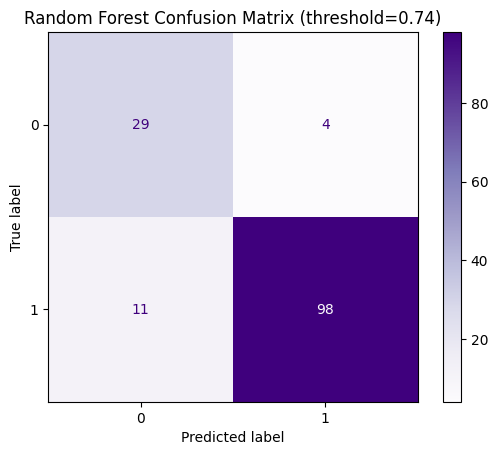

Random Forest Ensemble Results: {'Accuracy': 0.8943661971830986, 'F1': 0.9289099526066351, 'ROC AUC': np.float64(0.9527383931053657), 'Threshold': np.float64(0.74)}


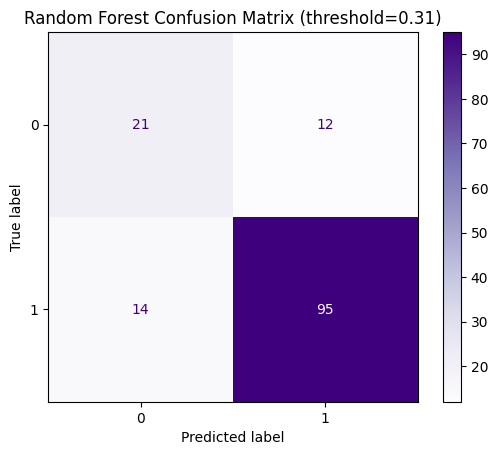

Only Audio Results: (RandomForestClassifier(max_depth=5, random_state=42), {'Accuracy': 0.8169014084507042, 'F1': 0.8796296296296297, 'ROC AUC': np.float64(0.8124826244092301), 'Threshold': np.float64(0.31)})


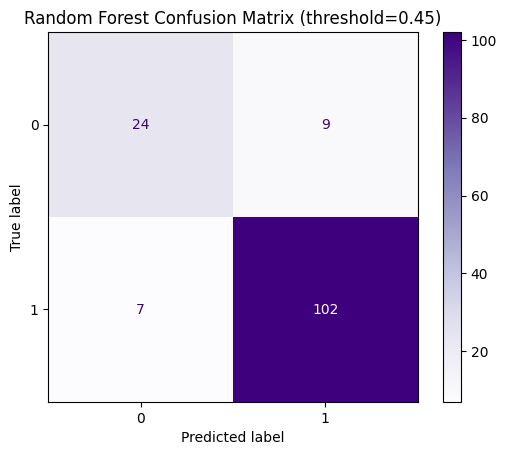

Only Video Results: (RandomForestClassifier(max_depth=5, random_state=42), {'Accuracy': 0.8873239436619719, 'F1': 0.9272727272727272, 'ROC AUC': np.float64(0.9496802891298305), 'Threshold': np.float64(0.45)})


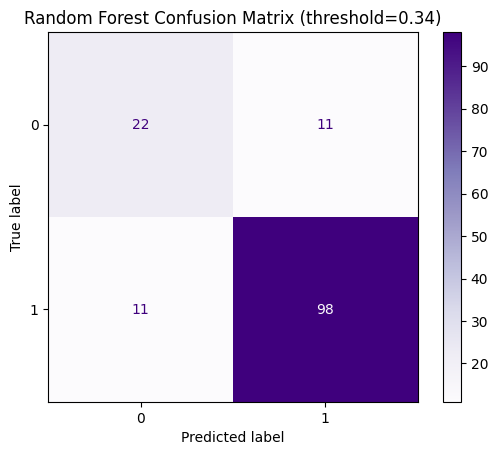

Only Forensic Results: (RandomForestClassifier(max_depth=5, random_state=42), {'Accuracy': 0.8450704225352113, 'F1': 0.8990825688073395, 'ROC AUC': np.float64(0.8415346121768141), 'Threshold': np.float64(0.34)})


In [ ]:
rf_model, results_rf = train_and_evaluate_random_forest_ensemble(
    logistic_modules_dict={
        "audio": audio_module,
        "video": video_module,
        "forensic": forensic_module,
    },
    X_train_dict={
        "audio": X_audio_train,
        "video": X_video_train,
        "forensic": X_forensic_train,
    },
    y_train_overall=y_train_overall,
    X_val_dict={
        "audio": X_audio_val,
        "video": X_video_val,
        "forensic": X_forensic_val,
    },
    y_val_overall=y_val_overall,
    X_test_dict={
        "audio": X_audio_test,
        "video": X_video_test,
        "forensic": X_forensic_test,
    },
    y_test_overall=y_test_overall
)
print("Random Forest Ensemble Results:", results_rf)

### Baseline Results (Same individual thresholds) ###

results_audio_baseline = train_and_evaluate_random_forest_ensemble(
    logistic_modules_dict={"Single Layer": audio_module},
    X_train_dict = {"Single Layer": X_audio_train},
    y_train_overall=y_train_overall,
    X_val_dict = {"Single Layer": X_audio_val},
    y_val_overall=y_val_overall,
    X_test_dict={"Single Layer": X_audio_test},
    y_test_overall=y_test_overall
    )
print("Only Audio Results:", results_audio_baseline)

results_video_baseline = train_and_evaluate_random_forest_ensemble(
    logistic_modules_dict={"Single Layer": video_module},
    X_train_dict = {"Single Layer": X_video_train},
    y_train_overall=y_train_overall,
    X_val_dict = {"Single Layer": X_video_val},
    y_val_overall=y_val_overall,
    X_test_dict={"Single Layer": X_video_test},
    y_test_overall=y_test_overall
    )
print("Only Video Results:", results_video_baseline)

results_forensic_baseline = train_and_evaluate_random_forest_ensemble(
    logistic_modules_dict={"Single Layer": forensic_module},
    X_train_dict = {"Single Layer": X_forensic_train},
    y_train_overall=y_train_overall,
    X_val_dict = {"Single Layer": X_forensic_val},
    y_val_overall=y_val_overall,
    X_test_dict={"Single Layer": X_forensic_test},
    y_test_overall=y_test_overall
    )
print("Only Forensic Results:", results_forensic_baseline)